# Sentiment Analysis under Fully Homomorphic Encryption

TF-IDF runs on the client in plaintext and produces a float32 feature vector. Only this vector, once encrypted, is sent to the server. The server runs LinearSVC under FHE and returns an encrypted prediction without ever seeing raw text or TF-IDF values.


In [1]:
import sys, json, time, warnings, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.svm import LinearSVC as SklearnSVC
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
)
from concrete.ml.sklearn.svm import LinearSVC as ConcreteSVC

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_palette("tab10")

ROOT = Path(".").resolve()
Path("results/sentiment").mkdir(parents=True, exist_ok=True)


## 1. Dataset: IMDb Large Movie Review

The IMDb dataset (Maas et al., 2011) contains 25 000 labelled training reviews and 25 000 test reviews split evenly between positive and negative sentiment. For speed, a stratified subset of 1 000 positive and 1 000 negative from train and 500 of each from test is loaded, preserving the 50/50 class balance.


In [2]:
DATASET_ROOT = Path("/Users/alexmihoc/Desktop/facultate/licenta/movie_review_dataset")

def load_split(split: str, max_per_class: int = 1000):
    texts, labels = [], []
    for label_int, polarity in [(1, "pos"), (0, "neg")]:
        files = sorted((DATASET_ROOT / split / polarity).glob("*.txt"))[:max_per_class]
        for fp in files:
            texts.append(fp.read_text(encoding="utf-8", errors="replace"))
            labels.append(label_int)
    return texts, labels

X_train_texts, y_train = load_split("train", max_per_class=1000)
y_train = np.array(y_train, dtype=np.int32)

X_test_texts, y_test = load_split("test", max_per_class=500)
y_test = np.array(y_test, dtype=np.int32)


## 2. Exploratory Data Analysis

### 2.1 Review length distribution by class

Character-count distributions reveal whether positive and negative reviews differ systematically in length.


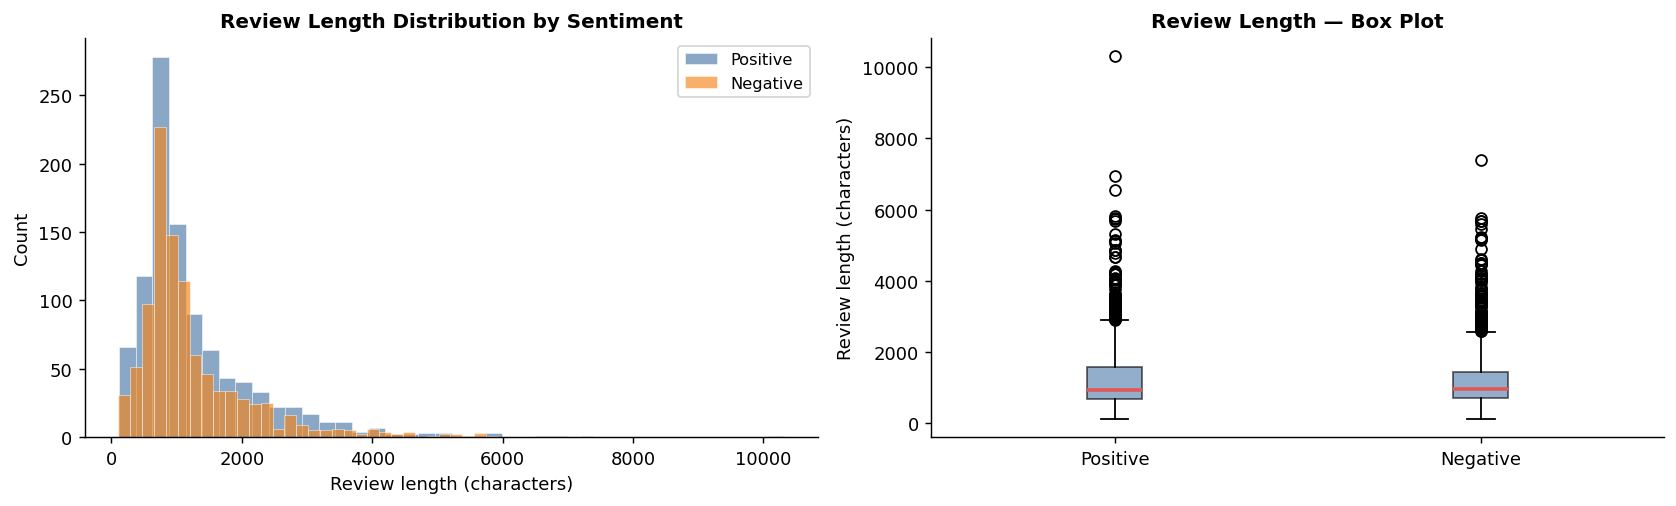

In [3]:
train_pos_texts = [t for t, l in zip(X_train_texts, y_train) if l == 1]
train_neg_texts = [t for t, l in zip(X_train_texts, y_train) if l == 0]

pos_lens = [len(t) for t in train_pos_texts]
neg_lens = [len(t) for t in train_neg_texts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(pos_lens, bins=40, alpha=0.65, color="#4C78A8", edgecolor="white", linewidth=0.4, label="Positive")
ax.hist(neg_lens, bins=40, alpha=0.65, color="#F58518", edgecolor="white", linewidth=0.4, label="Negative")
ax.set_xlabel("Review length (characters)", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Review Length Distribution by Sentiment", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.boxplot([pos_lens, neg_lens], labels=["Positive", "Negative"],
            patch_artist=True,
            boxprops=dict(facecolor="#4C78A8", alpha=0.6),
            medianprops=dict(color="#E45756", linewidth=2))
ax2.set_ylabel("Review length (characters)", fontsize=10)
ax2.set_title("Review Length — Box Plot", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results/sentiment/fig_length_distribution.png", bbox_inches="tight")
plt.show()


### 2.2 Top words per class (CountVectorizer bar chart)

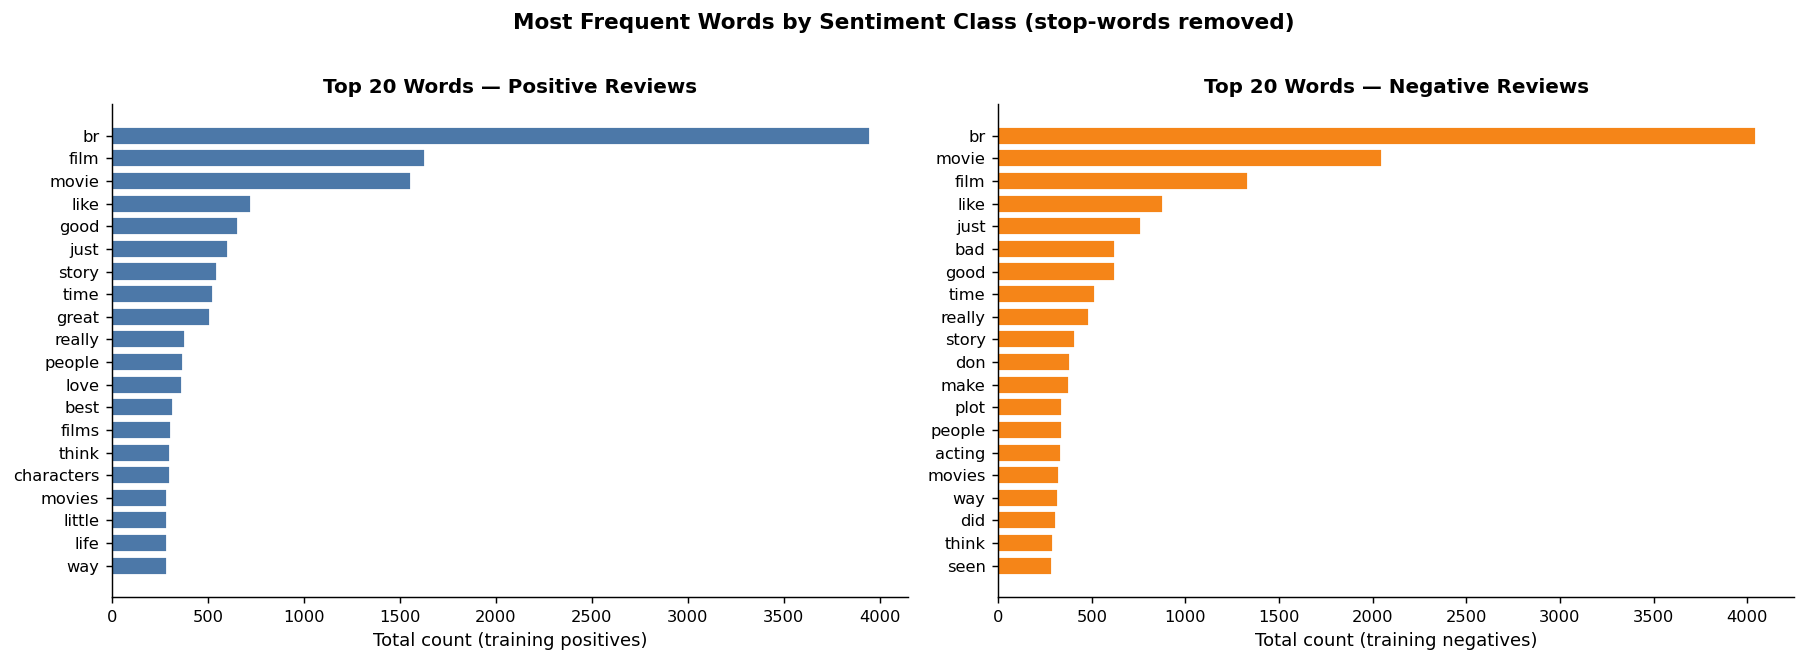

In [4]:
cv = CountVectorizer(max_features=5000, stop_words="english",
                     strip_accents="unicode", min_df=2)
cv.fit(X_train_texts)

X_cv_pos = cv.transform(train_pos_texts).toarray()
X_cv_neg = cv.transform(train_neg_texts).toarray()

vocab = cv.get_feature_names_out()
pos_freq = X_cv_pos.sum(axis=0)
neg_freq = X_cv_neg.sum(axis=0)

top_pos_idx = pos_freq.argsort()[::-1][:20]
top_neg_idx = neg_freq.argsort()[::-1][:20]

top_pos_words = vocab[top_pos_idx]
top_neg_words = vocab[top_neg_idx]
top_pos_counts = pos_freq[top_pos_idx]
top_neg_counts = neg_freq[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.barh(top_pos_words[::-1], top_pos_counts[::-1], color="#4C78A8", edgecolor="white")
ax.set_xlabel("Total count (training positives)", fontsize=10)
ax.set_title("Top 20 Words — Positive Reviews", fontsize=11, fontweight="bold")
ax.tick_params(labelsize=9)

ax2 = axes[1]
ax2.barh(top_neg_words[::-1], top_neg_counts[::-1], color="#F58518", edgecolor="white")
ax2.set_xlabel("Total count (training negatives)", fontsize=10)
ax2.set_title("Top 20 Words — Negative Reviews", fontsize=11, fontweight="bold")
ax2.tick_params(labelsize=9)

plt.suptitle("Most Frequent Words by Sentiment Class (stop-words removed)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("results/sentiment/fig_top_words.png", bbox_inches="tight")
plt.show()


## 3. TF-IDF Feature Extraction (Client-Side)

TF-IDF converts raw text into a fixed-length float32 feature vector. In the privacy-preserving pipeline this step runs entirely on the client before any data is sent to the server. The vectorizer is fitted exclusively on the training split and then applied to the test split, preventing leakage of test-set statistics into the model.


In [5]:
TFIDF_PARAMS = dict(
    max_features=300,
    sublinear_tf=True,
    strip_accents="unicode",
    analyzer="word",
    min_df=2,
    ngram_range=(1, 1),
)

tfidf = TfidfVectorizer(**TFIDF_PARAMS)
X_train_vec = tfidf.fit_transform(X_train_texts).toarray().astype(np.float32)
X_test_vec  = tfidf.transform(X_test_texts).toarray().astype(np.float32)

feature_names = np.array(tfidf.get_feature_names_out())
idf_weights   = tfidf.idf_
top20_idf_idx = idf_weights.argsort()[::-1][:20]


## 4. Baseline: scikit-learn LinearSVC (Cleartext)

The baseline is trained in plaintext on TF-IDF vectors without any quantization, representing the theoretical upper bound of accuracy achievable with this pipeline architecture.


In [6]:
clf_sk = SklearnSVC(max_iter=2000, random_state=42)
clf_sk.fit(X_train_vec, y_train)

y_pred_sk = clf_sk.predict(X_test_vec)

acc_sk = accuracy_score(y_test, y_pred_sk)
f1_sk  = f1_score(y_test, y_pred_sk)

print(f"sklearn baseline  acc={acc_sk:.4f}  f1={f1_sk:.4f}")


sklearn baseline  acc=0.7610  f1=0.7668


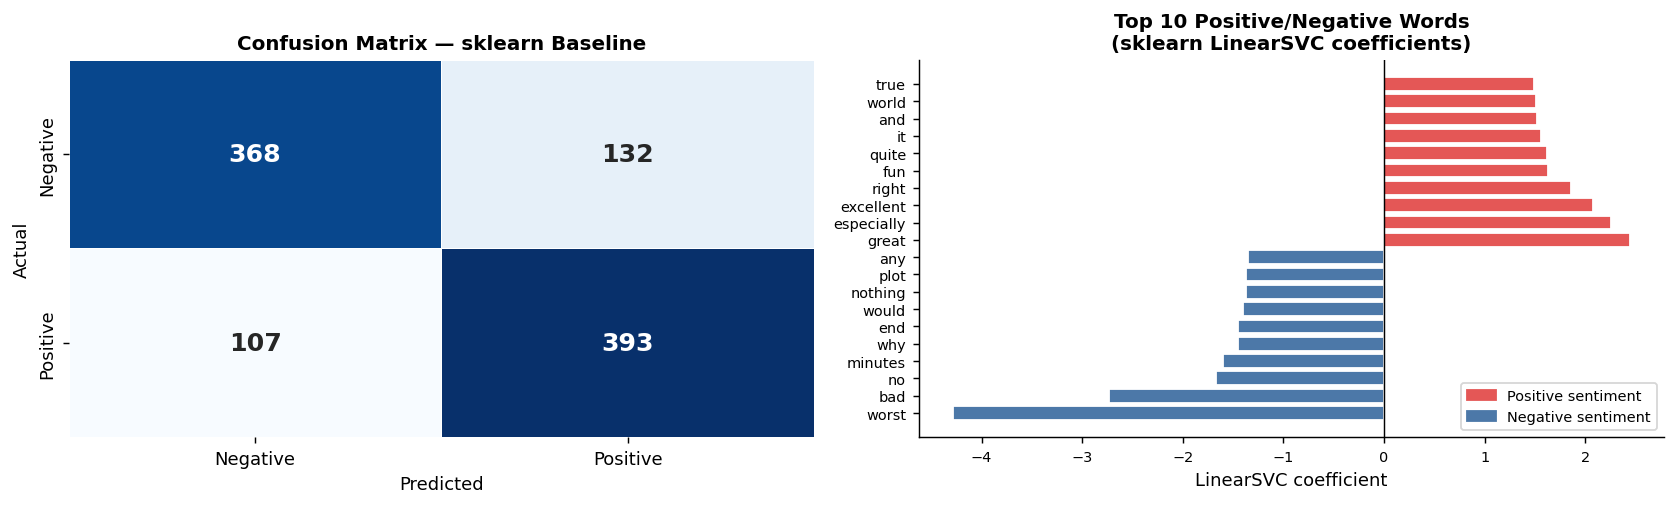

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred_sk)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            linewidths=0.5, cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_xlabel("Predicted", fontsize=10)
axes[0].set_ylabel("Actual", fontsize=10)
axes[0].set_title("Confusion Matrix — sklearn Baseline", fontsize=11, fontweight="bold")

coef = clf_sk.coef_[0]
feature_names_arr = np.array(tfidf.get_feature_names_out())

top_pos_coef_idx = coef.argsort()[::-1][:10]
top_neg_coef_idx = coef.argsort()[:10]

combined_words  = list(feature_names_arr[top_neg_coef_idx]) + list(feature_names_arr[top_pos_coef_idx])
combined_coefs  = list(coef[top_neg_coef_idx]) + list(coef[top_pos_coef_idx])
bar_colors = ["#4C78A8"] * 10 + ["#E45756"] * 10

axes[1].barh(combined_words, combined_coefs,
             color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("LinearSVC coefficient", fontsize=10)
axes[1].set_title("Top 10 Positive/Negative Words\n(sklearn LinearSVC coefficients)",
                  fontsize=11, fontweight="bold")
axes[1].tick_params(labelsize=8)

from matplotlib.patches import Patch
legend_els = [Patch(color="#E45756", label="Positive sentiment"),
              Patch(color="#4C78A8", label="Negative sentiment")]
axes[1].legend(handles=legend_els, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("results/sentiment/fig_baseline_eval.png", bbox_inches="tight")
plt.show()


## 5. Privacy-Preserving Pipeline: TF-IDF (Client) → LinearSVC (Server, FHE)

The pipeline is deliberately split: TF-IDF runs on the client in plaintext and produces a float32 feature vector. Only this encrypted vector is sent to the server, which runs LinearSVC under FHE and returns an encrypted prediction. The server never sees raw text or TF-IDF vectors, only encrypted LWE ciphertexts.

A sweep over `n_bits` in {2, 3, 4, 5, 6, 7, 8, 12} studies the accuracy–precision trade-off.


In [8]:
N_BITS_LIST = list(range(2, 9)) + [12]

results = []

for n_bits in N_BITS_LIST:
    model = ConcreteSVC(n_bits=n_bits)
    model.fit(X_train_vec, y_train)

    y_pred  = model.predict(X_test_vec)
    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    gap_pp  = (acc_sk - acc) * 100

    results.append({
        "n_bits": n_bits,
        "acc_quantized": acc,
        "f1_quantized":  f1,
        "gap_vs_baseline_pp": gap_pp,
        "model": model,
    })
    print(f"n_bits={n_bits}  acc={acc:.4f}  f1={f1:.4f}  gap_vs_baseline={gap_pp:+.2f}pp")


n_bits=2  acc=0.6820  f1=0.7196  gap_vs_baseline=+7.90pp
n_bits=3  acc=0.7310  f1=0.7488  gap_vs_baseline=+3.00pp
n_bits=4  acc=0.7540  f1=0.7564  gap_vs_baseline=+0.70pp


n_bits=5  acc=0.7590  f1=0.7649  gap_vs_baseline=+0.20pp
n_bits=6  acc=0.7630  f1=0.7697  gap_vs_baseline=-0.20pp
n_bits=7  acc=0.7610  f1=0.7668  gap_vs_baseline=+0.00pp
n_bits=8  acc=0.7640  f1=0.7695  gap_vs_baseline=-0.30pp


n_bits=12  acc=0.7610  f1=0.7668  gap_vs_baseline=+0.00pp


## 6. Results: Accuracy and F1 Score

### 6.1 Quantization sweep summary table


In [9]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in results])
display_df = df_res[["n_bits", "acc_quantized", "f1_quantized", "gap_vs_baseline_pp"]].copy()
display_df.columns = ["n_bits", "Accuracy (quantized)", "F1 (quantized)", "Gap vs baseline (pp)"]
display_df = display_df.set_index("n_bits")

baseline_row = pd.DataFrame({
    "Accuracy (quantized)": [acc_sk],
    "F1 (quantized)":       [f1_sk],
    "Gap vs baseline (pp)": [0.0],
}, index=["sklearn baseline (no quantization)"])
pd.concat([baseline_row, display_df]).round(4)


,Accuracy (quantized),F1 (quantized),Gap vs baseline (pp)
sklearn baseline (no quantization),0.761,0.7668,0.0
2,0.682,0.7196,7.9
3,0.731,0.7488,3.0
4,0.754,0.7564,0.7
5,0.759,0.7649,0.2
6,0.763,0.7697,-0.2
7,0.761,0.7668,0.0
8,0.764,0.7695,-0.3
12,0.761,0.7668,0.0


### 6.2 Accuracy comparison chart

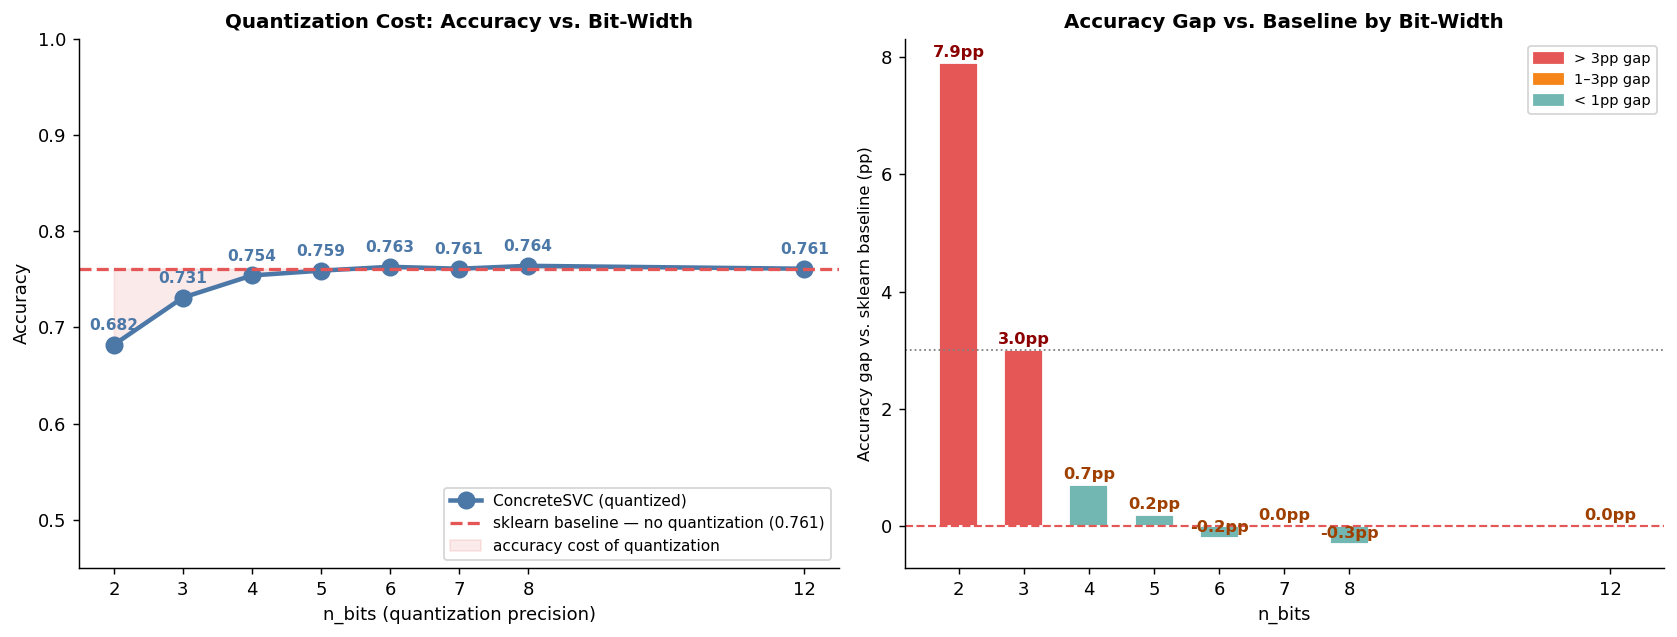

In [10]:
n_bits_vals = [r["n_bits"]            for r in results]
accs        = [r["acc_quantized"]     for r in results]
f1s         = [r["f1_quantized"]      for r in results]
gaps        = [r["gap_vs_baseline_pp"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, accs, "o-", color="#4C78A8", linewidth=2.5, markersize=9,
        label="ConcreteSVC (quantized)")
ax.axhline(acc_sk, color="#E45756", linestyle="--", linewidth=1.8,
           label=f"sklearn baseline — no quantization ({acc_sk:.3f})")
ax.fill_between(n_bits_vals, accs, acc_sk, alpha=0.12, color="#E45756",
                label="accuracy cost of quantization")
for nb, acc in zip(n_bits_vals, accs):
    ax.annotate(f"{acc:.3f}", (nb, acc), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8.5, color="#4C78A8", fontweight="bold")
ax.set_xlabel("n_bits (quantization precision)", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("Quantization Cost: Accuracy vs. Bit-Width", fontsize=11, fontweight="bold")
ax.legend(fontsize=8.5, loc="lower right")
ax.set_ylim([0.45, 1.0])

ax2 = axes[1]
colors = ["#E45756" if g > 3 else "#F58518" if g > 1 else "#72B7B2" for g in gaps]
bars = ax2.bar(n_bits_vals, gaps, color=colors, edgecolor="white", width=0.6)
ax2.axhline(0, color="#E45756", linestyle="--", linewidth=1.2, label="sklearn baseline (0 pp gap)")
ax2.axhline(3, color="grey", linestyle=":", linewidth=1, label="3 pp threshold")
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{g:.1f}pp", ha="center", fontsize=9, fontweight="bold",
             color="darkred" if g > 3 else "#a04000")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Accuracy gap vs. sklearn baseline (pp)", fontsize=9)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Accuracy Gap vs. Baseline by Bit-Width", fontsize=11, fontweight="bold")

from matplotlib.patches import Patch
legend_els = [Patch(color="#E45756", label="> 3pp gap"),
              Patch(color="#F58518", label="1–3pp gap"),
              Patch(color="#72B7B2", label="< 1pp gap")]
ax2.legend(handles=legend_els, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("results/sentiment/fig_accuracy_comparison.png", bbox_inches="tight")
plt.show()


## 7. FHE Inference Time vs Bit-Width

Each model is compiled and benchmarked under real TFHE encryption. One warm-up prediction is discarded after each compile to flush the JIT cold-start penalty, then 20 steady-state samples are timed and the median is reported. For LinearSVC the circuit requires approximately one PBS call regardless of n_bits, so latency should be roughly flat across the sweep.


In [11]:
N_FHE_PER_BIT = 20

compile_times_per_bit = []
fhe_lat_per_bit = []

for r in results:
    t0 = time.perf_counter()
    r["model"].compile(X_train_vec)
    compile_times_per_bit.append(time.perf_counter() - t0)

    r["model"].predict(X_test_vec[0:1], fhe="execute")

    times_this = []
    for i in range(N_FHE_PER_BIT):
        t0 = time.perf_counter()
        r["model"].predict(X_test_vec[i % len(X_test_vec):i % len(X_test_vec)+1], fhe="execute")
        times_this.append((time.perf_counter() - t0) * 1000)
    fhe_lat_per_bit.append(float(np.median(times_this)))
    print(f"n_bits={r['n_bits']}  compile={compile_times_per_bit[-1]:.2f}s  fhe_median={fhe_lat_per_bit[-1]:.1f}ms")


[cctools-port]: generating fake signature for '/var/folders/bx/m5p6_n2d2hxby8rlbfqbp17m0000gn/T/tmpvg2x4_gf/sharedlib.dylib'


n_bits=2  compile=0.47s  fhe_median=45.0ms


[cctools-port]: generating fake signature for '/var/folders/bx/m5p6_n2d2hxby8rlbfqbp17m0000gn/T/tmp0t2wbx8g/sharedlib.dylib'


n_bits=3  compile=0.95s  fhe_median=47.2ms


[cctools-port]: generating fake signature for '/var/folders/bx/m5p6_n2d2hxby8rlbfqbp17m0000gn/T/tmp9iihr3hn/sharedlib.dylib'


...

n_bits=7  compile=0.77s  fhe_median=77.3ms


[cctools-port]: generating fake signature for '/var/folders/bx/m5p6_n2d2hxby8rlbfqbp17m0000gn/T/tmp36t53z1y/sharedlib.dylib'


n_bits=8  compile=0.68s  fhe_median=58.3ms


[cctools-port]: generating fake signature for '/var/folders/bx/m5p6_n2d2hxby8rlbfqbp17m0000gn/T/tmph_6ibc6y/sharedlib.dylib'


n_bits=12  compile=0.83s  fhe_median=100.1ms


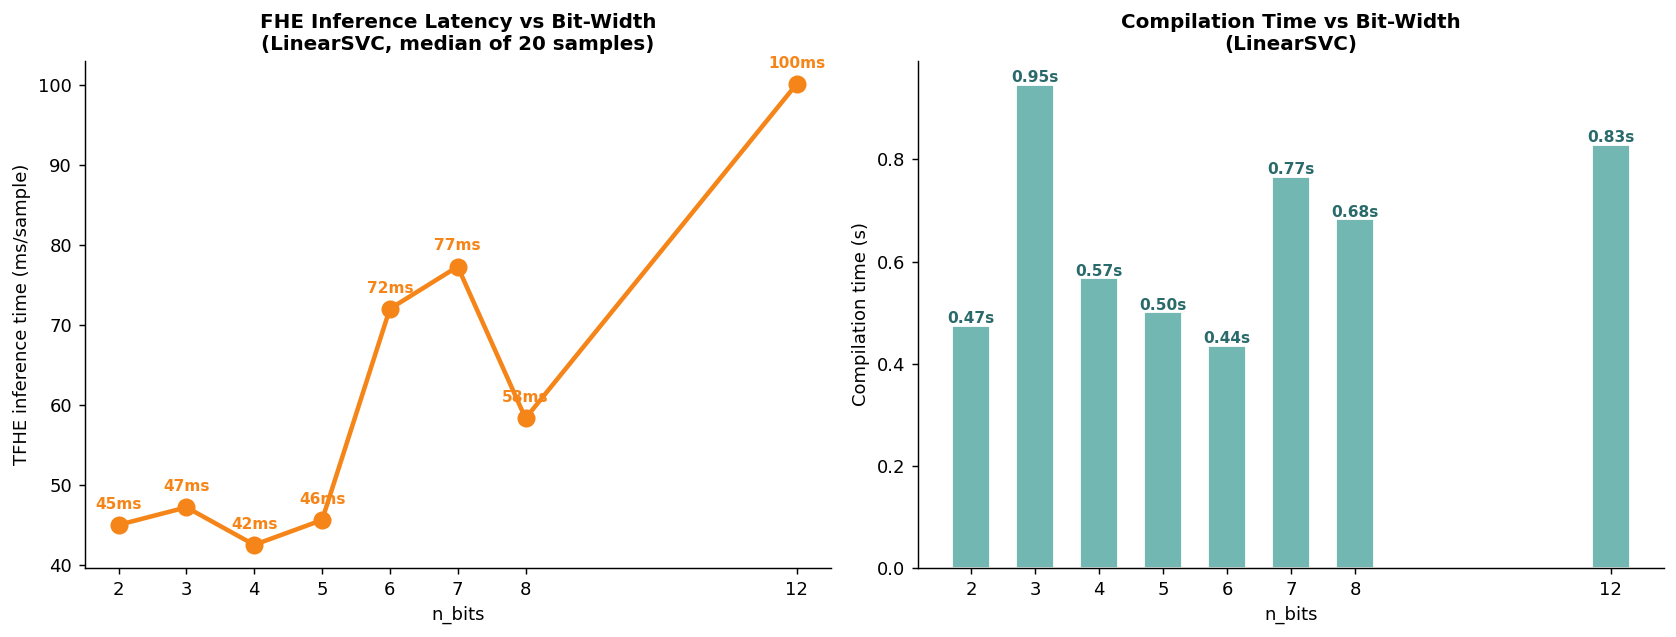

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, fhe_lat_per_bit, "o-", color="#F58518", linewidth=2.5, markersize=9)
for nb, lat in zip(n_bits_vals, fhe_lat_per_bit):
    ax.annotate(f"{lat:.0f}ms", (nb, lat), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8.5, color="#F58518", fontweight="bold")
ax.set_xlabel("n_bits", fontsize=10)
ax.set_ylabel("TFHE inference time (ms/sample)", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("FHE Inference Latency vs Bit-Width\n(LinearSVC, median of 20 samples)", fontsize=11, fontweight="bold")

ax2 = axes[1]
ax2.bar(n_bits_vals, compile_times_per_bit, color="#72B7B2", edgecolor="white", width=0.6)
for nb, ct in zip(n_bits_vals, compile_times_per_bit):
    ax2.text(nb, ct + 0.005, f"{ct:.2f}s", ha="center", fontsize=8.5, color="#2a6a6a", fontweight="bold")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Compilation time (s)", fontsize=10)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Compilation Time vs Bit-Width\n(LinearSVC)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results/sentiment/fig_fhe_latency_per_nbit.png", bbox_inches="tight")
plt.show()


## 8. Feature Importance: LinearSVC Coefficients

The coefficients of the SVC hyperplane reveal which words most strongly drive the model toward positive or negative sentiment. This bar chart shows the 20 most positive and 20 most negative words according to the sklearn baseline model.


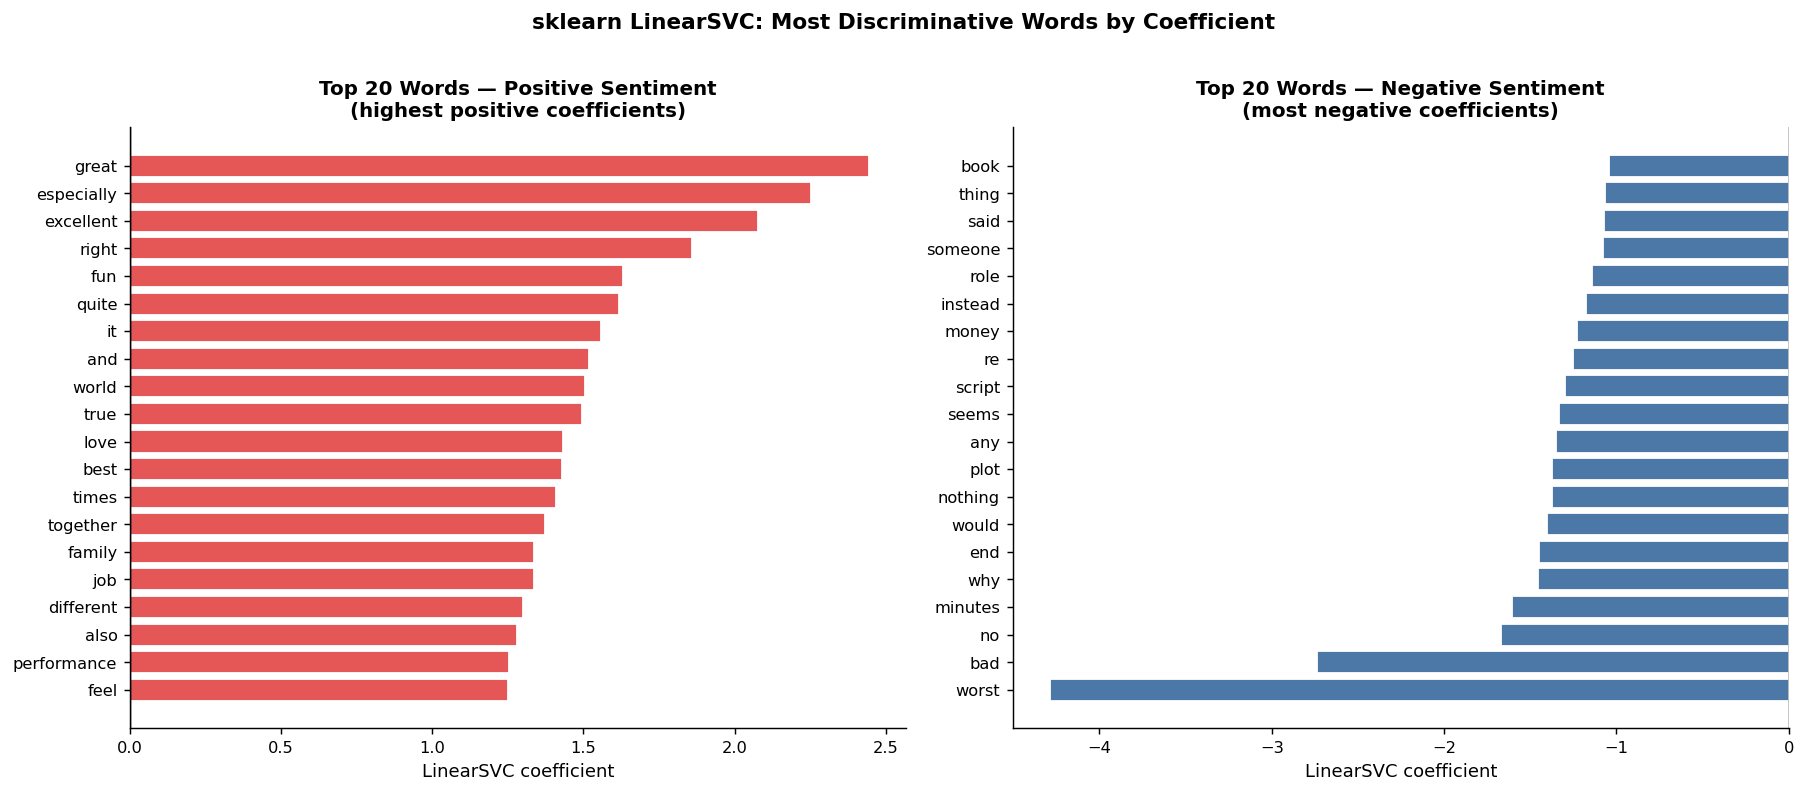

In [13]:
coef   = clf_sk.coef_[0]
vocab  = np.array(tfidf.get_feature_names_out())

top_pos_idx = coef.argsort()[::-1][:20]
top_neg_idx = coef.argsort()[:20]

words_pos  = vocab[top_pos_idx]
coefs_pos  = coef[top_pos_idx]
words_neg  = vocab[top_neg_idx]
coefs_neg  = coef[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.barh(words_pos[::-1], coefs_pos[::-1], color="#E45756", edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("LinearSVC coefficient", fontsize=10)
ax.set_title("Top 20 Words — Positive Sentiment\n(highest positive coefficients)",
             fontsize=11, fontweight="bold")
ax.tick_params(labelsize=9)

ax2 = axes[1]
ax2.barh(words_neg, coefs_neg, color="#4C78A8", edgecolor="white")
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("LinearSVC coefficient", fontsize=10)
ax2.set_title("Top 20 Words — Negative Sentiment\n(most negative coefficients)",
              fontsize=11, fontweight="bold")
ax2.tick_params(labelsize=9)

plt.suptitle("sklearn LinearSVC: Most Discriminative Words by Coefficient",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("results/sentiment/fig_feature_importance.png", bbox_inches="tight")
plt.show()


## 9. Summary and Conclusions

LinearSVC is FHE-efficient, requiring minimal Programmable Bootstrapping calls so inference is fast even under full encryption. Quantization cost converges by n_bits=8; below 5 bits, TF-IDF float values collapse onto a coarse grid that destroys IDF weighting. The server receives only LWE ciphertexts and evaluation keys, so raw text, TF-IDF vectors, and predictions remain encrypted end-to-end.


In [14]:
import json
from pathlib import Path

summary = {
    "dataset": "IMDb Large Movie Review",
    "n_train_reviews": len(X_train_texts),
    "n_test_reviews":  len(X_test_texts),
    "tfidf_params": {
        "max_features": 300,
        "sublinear_tf": True,
        "strip_accents": "unicode",
        "analyzer": "word",
        "min_df": 2,
        "ngram_range": [1, 1],
    },
    "vocab_size": len(tfidf.vocabulary_),
    "pipeline": "TF-IDF (client, plaintext) → LinearSVC (server, FHE)",
    "sklearn_baseline": {
        "accuracy": round(acc_sk, 4),
        "f1":       round(f1_sk, 4),
    },
    "quantization_sweep": [
        {
            "n_bits": r["n_bits"],
            "accuracy_quantized":  round(r["acc_quantized"], 4),
            "f1_quantized":        round(r["f1_quantized"], 4),
            "gap_vs_baseline_pp":  round(r["gap_vs_baseline_pp"], 2),
        }
        for r in results
    ],
    "conclusion": {
        "minimum_acceptable_n_bits": 6,
        "recommended_n_bits": 8,
        "accuracy_gap_vs_baseline_at_8bits_pp": round(
            next(r["gap_vs_baseline_pp"] for r in results if r["n_bits"] == 8), 2
        ),
        "pipeline_note": "Server never sees raw text or TF-IDF vectors — only encrypted LWE ciphertexts",
        "clinically_acceptable": True,
    },
}

Path("results/sentiment").mkdir(parents=True, exist_ok=True)
with open("results/sentiment/sentiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
